# Machine learning introduction

## Intro
* To get started, please write 5 examples of the application of ML methods in life. What is the benefit of using machine learning methods in each of your examples?
* Use the classification of tasks in the introduction to decide which class you can assign to the tasks from the table above and to the 5 examples you provided.
* Think about what the difference is between multiclass and multilabel.
* Is an example case with house prices from the theory a classification of a regression problem? Is it possible to reduce the regression problem to classification?

### A. 5 examples of the application of ML methods in life
1. <b>Recommendation systems</b><br>
High personalization, finding hidden connections, can match even for new users and scalability
2. <b>Natural language processing</b><br>
Understanding the context, high data processing speed, search for hidden patterns and multilingualism
3. <b>Presonal assistants</b><br>
Natural communication, user adaptation and continuous improvement
4. <b>Fraud detection</b><br>
Speed of detection, search for hidden patterns, adaptability, behavior analysis and reduction of false positives
5. <b>Self-driving cars</b><br>
Safety, fatigue-free work, predictive driving and continuous learning

###  B. Classification of tasks
1. Predict house price - <b>regression</b>
2. Predict whether a client returns a loan - <b>binary classification</b>
3. Predict when a patient needs to take medicine - <b>regression</b>
4. Choose what medicine out of available a patient should take - <b>multiclass</b>
5. Choose segment of clients for a promo communication - <b>association</b>
6. Recognition of defective products on the production line (based on photo scans) - <b>binary classification</b>
7. Decide how to place products on a shelf in a store - <b>clustering</b>
8. Search sites for input text query - <b>ranking</b>
9. Split customers of a store into segments to understand differences of their behavior - <b>clustering</b>
10. Detect anomaly in site traffic - <b>binary classification</b>
11. Recommendation systems - <b>binary classification/ranking</b>
12. Natural language processing - <b>classification, regression, Seq2Seq</b>
13. Presonal assistants - <b>Seq2Seq</b>
14. Fraud detection - <b>binary classification</b>
15. Self-driving cars - <b>computer vision, regression</b>

### C. The difference between multiclass and multilabel
In multiclass classification, one label corresponds to one object; in multi-label classification, each object can have several labels. 

The multiclass classification is suitable for tasks where <b>one answer</b> is important, and the multi-label classification is suitable for tasks where you need to predict a <b>set of labels</b>.

### D. The type of example case
The example case is a <b>regression</b> task, but it can be reduced to a classification task, for example, predicting whether the target variable will be greater than a certain price (binary classification), or predicting the price range that the target variable belongs to (multiclass classification)

## Introduction to Data Analysis

In [1]:
import pandas as pd
import numpy as np
import sklearn
import lightgbm
import scipy
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_json('data/train.json')

In [3]:
df.shape

(49352, 15)

In [6]:
df.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [8]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [10]:
df.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [5]:
need_columns = ['bathrooms', 'bedrooms', 'interest_level', 'price']

train_df = df[need_columns].copy()

In [4]:
train_df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


## Statistical Data Analysis

### Plot a histogram to understand the distribution of the target

Text(0.5, 1.0, 'Target distribution')

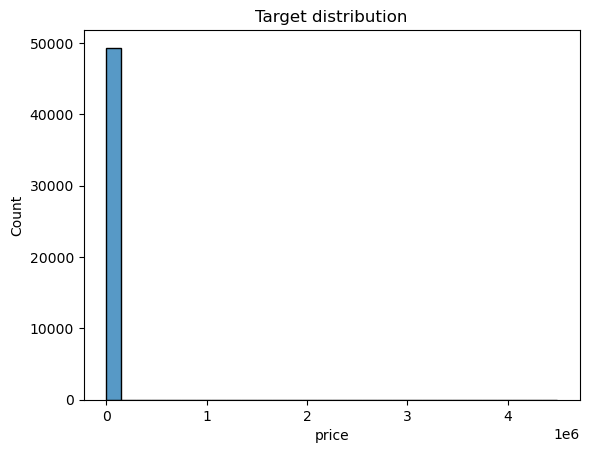

In [7]:
sns.histplot(data=train_df, x='price', bins=30)
plt.title('Target distribution')

### Boxplot

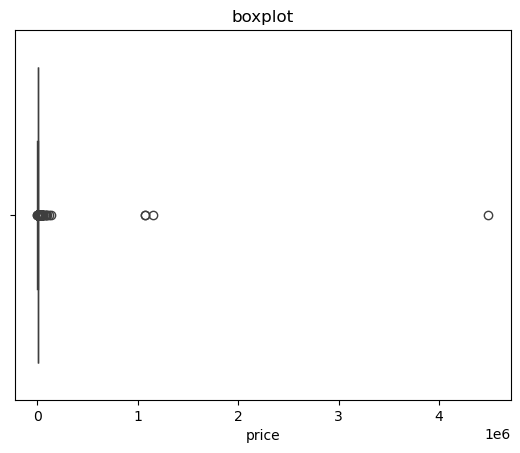

In [15]:
sns.boxplot(data=train_df, x='price');
plt.title('boxplot');

### Drop the rows that are outside the 1 and 99 percentiles from the target column.

In [6]:
low, high = np.percentile(train_df['price'], [1, 99])

train_filtered = train_df[(train_df['price'] >= low) & (train_df['price'] <= high)].copy()

###  Plot another histogram for price

Text(0.5, 1.0, 'Target distribution')

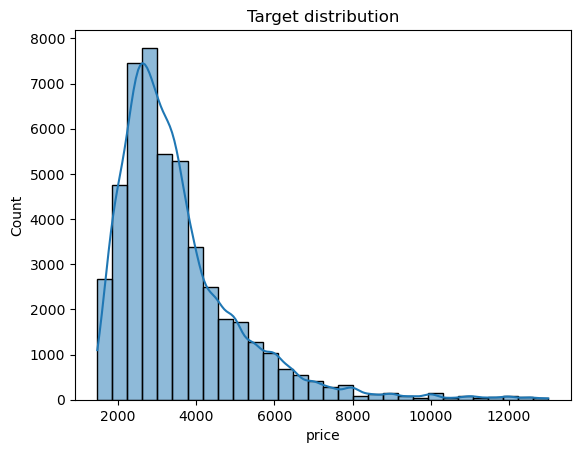

In [24]:
sns.histplot(data=train_filtered, x='price', bins=30, kde=True)
plt.title('Target distribution')

### Characteristics Analysis
* interest_level dtype

In [33]:
train_filtered.dtypes

bathrooms         float64
bedrooms            int64
interest_level     object
price               int64
dtype: object

* Print the values in this column. How many entries does each value contain?

In [52]:
train_filtered.interest_level.unique()

array(['medium', 'low', 'high'], dtype=object)

In [53]:
train_filtered.interest_level.value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

* Encode these values. For example, you can replace each value with 0, 1, or 2.

In [7]:
codes = {
    'low': 0,
    'medium': 1,
    'high': 2
}

train_filtered['interest_level'] = train_filtered['interest_level'].apply(lambda x: codes[x])

* Plot histograms for the features 'bathrooms', 'bedrooms'. Are there any outliers?

Text(0.5, 0.98, 'Features distribution')

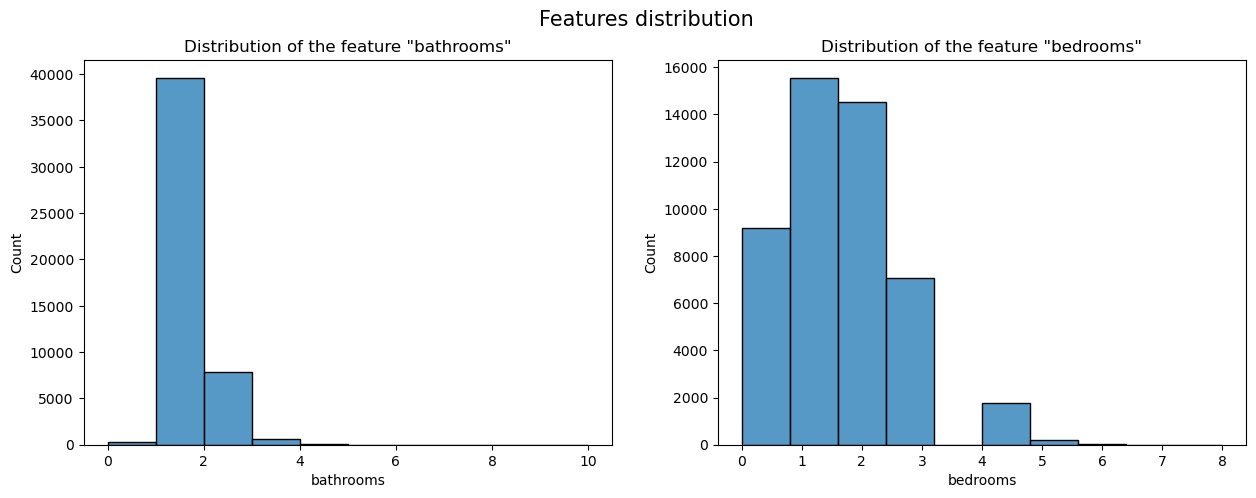

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=train_filtered, x='bathrooms', ax=axes[0], bins=10)
sns.histplot(data=train_filtered, x='bedrooms', ax=axes[1], bins=10)

axes[0].set_title('Distribution of the feature "bathrooms"')
axes[1].set_title('Distribution of the feature "bedrooms"')

fig.suptitle('Features distribution', fontsize=15)

### Complex analysis
* Plot a correlation matrix to understand the correlation between features and target. Plot a heat map for the correlation matrix. Is there a correlation?

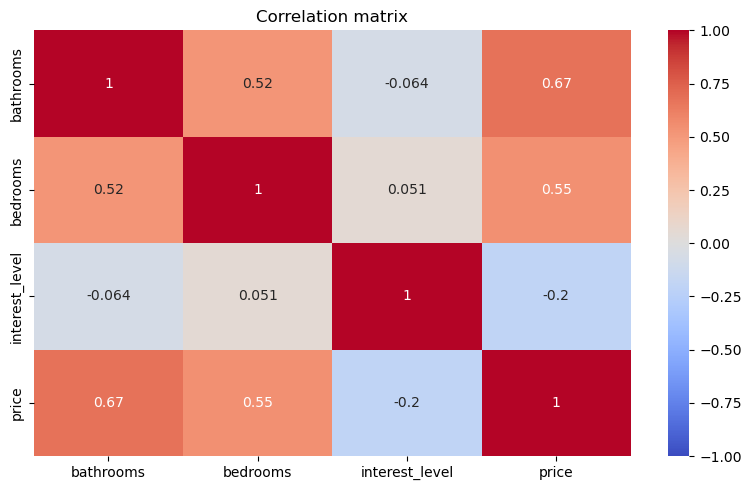

In [11]:
corr_matrix = train_filtered.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

* Plot a scatterplot to visualize the correlation between the features and the target. You should return 3 plots where the X-axis is the target and the Y-axis is a feature.

Text(0.5, 0.98, 'Correlation')

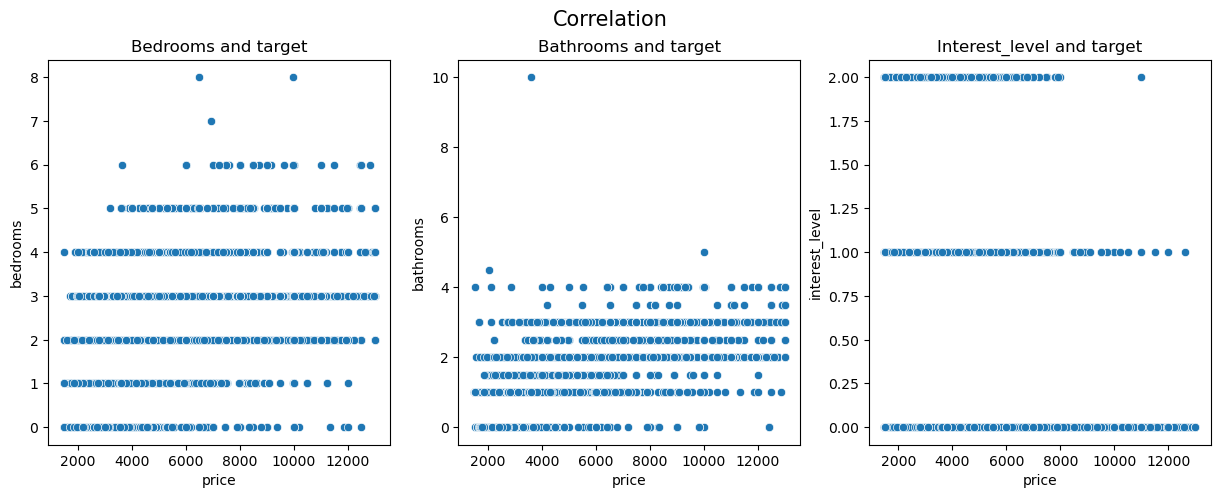

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=train_filtered, x='price', y='bedrooms', ax=axes[0])
sns.scatterplot(data=train_filtered, x='price', y='bathrooms', ax=axes[1])
sns.scatterplot(data=train_filtered, x='price', y='interest_level', ax=axes[2])

axes[0].set_title('Bedrooms and target')
axes[1].set_title('Bathrooms and target')
axes[2].set_title('Interest_level and target')

fig.suptitle('Correlation', fontsize=15)

## Creating Features
* This step is very broad. You can create as many features as you want. For example, you can add 3 new features that are squared: 'bathrooms_squared', 'bedrooms_squared', ''interest_level_squared'. Plot a correlation matrix with the new features. Are the new features more correlated with the target than the basic features?

In [25]:
train_filtered['bathrooms_squared'] = train_filtered['bathrooms'].apply(lambda x: x**2)
train_filtered['bedrooms_squared'] = train_filtered['bedrooms'].apply(lambda x: x**2)
train_filtered['interest_level_squared'] = train_filtered['interest_level'].apply(lambda x: x**2)

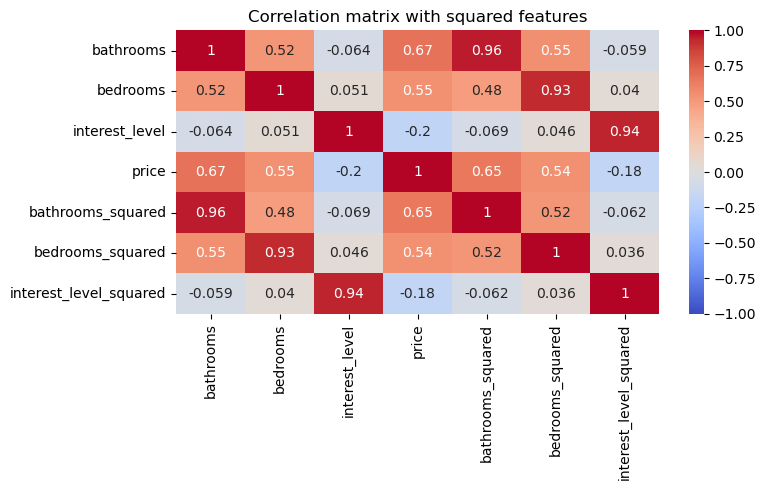

In [27]:
corr_matrix = train_filtered.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation matrix with squared features')
plt.tight_layout()
plt.show()

* To train the model here, we will not use your new features. Remember this example and use it in Lecture 2. To train the model, we will only consider the features 'bathrooms' and 'bedrooms'.
* To use PolynomialFeatures, we first need to split the data into training and test samples. We have already done this for you, please read the training and test data.

In [106]:
train = pd.read_json('data/train.json')
test = pd.read_json('data/test.json')

In [107]:
need_columns = ['bathrooms', 'bedrooms', 'price']

low_train, high_train = np.percentile(train['price'], [1, 99])
low_test, high_test = np.percentile(test['price'], [1, 99])

# delete outliers in "bathrooms" feature
low_bath, high_bath = np.percentile(test['bathrooms'], [1, 99])

train = train[need_columns]
train = train[(train['price'] >= low_train) & (train['price'] <= high_train)]

test = test[need_columns]
test = test[(test['price'] >= low_test) & (test['price'] <= high_test)]
test = test[(test['bathrooms'] >= low_bath) & (test['bathrooms'] <= high_bath)]

In [108]:
X_train = train.drop('price', axis=1)
y_train = train['price']

X_test = test.drop('price', axis=1)
y_test = test['price']

* Initialize PolynomialFeatures() with a degree of 10.
* Apply PolynomialFeatures() to fit and transform your training and test data.

In [109]:
poly = PolynomialFeatures(10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

## ML models
* Create two empty Pandas DataFrames with columns 'model', 'train', 'test'. Let's call the first one result_MAE and the second one result_RMSE. We will fill these tables with the results of the models.

In [110]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = result_MAE.copy()

### Linear Regression
* Initialize linear regression from sklearn with no parameters.

In [111]:
lr_model = LinearRegression()

* Fit your model and make predictions on training and test features. Save it as new columns in data.

In [112]:
lr_model.fit(X_train_poly, y_train)

train['predicted'] = lr_model.predict(X_train_poly)
test['predicted'] = lr_model.predict(X_test_poly)

* Compute MAE (Mean Absolute Error) on training and test targets.

In [113]:
lr_mae_train = mean_absolute_error(y_train, train['predicted'])
lr_mae_test = mean_absolute_error(y_test, test['predicted'])

* Calculate RMSE (Root Mean Square Error) on training and test objectives.

In [114]:
lr_rmse_train = root_mean_squared_error(y_train, train['predicted'])
lr_rmse_test = root_mean_squared_error(y_test, test['predicted'])

* Insert your metrics into tables result_MAE and result_RMSE with model name 'linear_regression'.

In [115]:
mae_row = pd.DataFrame({'model': 'linear_regression', 'train': [lr_mae_train], 'test': [lr_mae_test]})
rmse_row = pd.DataFrame({'model': 'linear_regression', 'train': [lr_rmse_train], 'test': [lr_rmse_test]})

result_MAE = mae_row
result_RMSE = rmse_row

### Decision Tree
* Initialize decision tree regressor from sklearn with fixed random_state=21.

In [120]:
dt_model = DecisionTreeRegressor(random_state=21)

* Fit it to train features and train target and make prediction on train and test features. Save it as a new column in data.

In [121]:
dt_model.fit(X_train_poly, y_train)

train['predicted'] = dt_model.predict(X_train_poly)
test['predicted'] = dt_model.predict(X_test_poly)

* Compute MAE (Mean Absolute Error) on train and test targets.

In [122]:
dt_mae_train = mean_absolute_error(y_train, train['predicted'])
dt_mae_test = mean_absolute_error(y_test, test['predicted'])

* Compute RMSE (Root Mean Square Error) on train and test targets.

In [123]:
dt_rmse_train = root_mean_squared_error(y_train, train['predicted'])
dt_rmse_test = root_mean_squared_error(y_test, test['predicted'])

* Insert your metrics into tables result_MAE and result_RMSE with model name 'decision_tree'.

In [124]:
mae_row = pd.DataFrame({'model': 'decision_tree', 'train': [dt_mae_train], 'test': [dt_mae_test]})
rmse_row = pd.DataFrame({'model': 'decision_tree', 'train': [dt_rmse_train], 'test': [dt_rmse_test]})

result_MAE = pd.concat([result_MAE, mae_row], ignore_index=True, join='inner')
result_RMSE = pd.concat([result_RMSE, rmse_row], ignore_index=True, join='inner')

### Naive Models
* Calculate the mean and median of 'price' on the training and test data and create a column with these values.

In [132]:
mean_train, mean_test = train.price.mean(), test.price.mean()
median_train, median_test = train.price.median(), test.price.median()

train['predicted_mean'] = [mean_train] * len(X_train_poly)
test['predicted_mean'] = [mean_test] * len(X_test_poly)

train['predicted_median'] = [median_train] * len(X_train_poly)
test['predicted_median'] = [median_test] * len(X_test_poly)

* Calculate the MAE on the training and test targets between your target and the calculated mean and median.

In [135]:
mean_mae_train = mean_absolute_error(y_train, train['predicted_mean'])
mean_mae_test = mean_absolute_error(y_test, test['predicted_mean'])

median_mae_train = mean_absolute_error(y_train, train['predicted_median'])
median_mae_test = mean_absolute_error(y_test, test['predicted_median'])

* Calculate the RMSE on the training and test targets between your target and the calculated mean and median.

In [136]:
mean_rmse_train = mean_absolute_error(y_train, train['predicted_mean'])
mean_rmse_test = mean_absolute_error(y_test, test['predicted_mean'])

median_rmse_train = root_mean_squared_error(y_train, train['predicted_median'])
median_rmse_test = root_mean_squared_error(y_test, test['predicted_median'])

* Insert your metrics into tables result_MAE and result_RMSE with model names 'naive_mean' and 'naive_median'.

In [ ]:
mae_mean_row = pd.DataFrame({'model': 'naive_mean', 'train': [mean_mae_train], 'test': [mean_mae_test]})
rmse_mean_row = pd.DataFrame({'model': 'naive_mean', 'train': [mean_rmse_train], 'test': [mean_rmse_test]})

mae_median_row = pd.DataFrame({'model': 'naive_median', 'train': [median_mae_train], 'test': [median_mae_test]})
rmse_median_row = pd.DataFrame({'model': 'naive_median', 'train': [median_rmse_train], 'test': [median_rmse_test]})

result_MAE = pd.concat([result_MAE, mae_mean_row], ignore_index=True, join='inner')
result_RMSE = pd.concat([result_RMSE, rmse_mean_row], ignore_index=True, join='inner')

result_MAE = pd.concat([result_MAE, mae_median_row], ignore_index=True, join='inner')
result_RMSE = pd.concat([result_RMSE, rmse_median_row], ignore_index=True, join='inner')

### Compare the results
* Print your final result_MAE and result_RMSE tables.

In [138]:
result_MAE

,model,train,test
0,linear_regression,756.040299,768.748408
1,decision_tree,756.044735,756.132684
2,naive_mean,1139.192515,1121.708429
3,naive_median,1086.210505,1073.265761


In [139]:
result_RMSE

,model,train,test
0,linear_regression,1077.566356,1680.729259
1,decision_tree,1077.483596,1074.457612
2,naive_mean,1139.192515,1121.708429
3,naive_median,1644.236439,1603.632143


* Which is the best model?<br>
  Answer: <b>decision tree</b>